# Backcasting model performance figures

This notebook evaluates the final global XGBoost model on a spatially independent test set and creates publication-ready performance figures.

Outputs:

- precision–recall curve with the selected threshold marked;
- normalized confusion matrix at the selected threshold;
- combined two-panel main-text figure;
- calibration plot;
- ROC curve;
- CSV table with test-set performance metrics.

The tile split is reconstructed using the proportions used for model development: 70% training, 15% validation, and 15% testing, with seed 42. The classification threshold is selected **only on the validation set** as the lowest threshold reaching the target precision of 0.85 for the forest-continuity class. All reported metrics are then calculated on the untouched test set.


In [1]:
# Imports

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb

from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)


In [2]:
# ------------------------------------------------------------
# SETTINGS — check these paths before running
# ------------------------------------------------------------

TRAINING_DATA_DIR = Path("/mnt/eo/EO4Backcasting/training_data")
TRAINING_FILE_PATTERN = "training_data_stm.csv"

MODEL_PATH = Path("/mnt/eo/EO4Backcasting/_models/global/xgb_model_final.json")

OUTPUT_DIR = Path("/mnt/eo/EO4Backcasting/_figs/model_performance")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_COLUMN = "label_undisturbed_20y"
TILE_COLUMN = "tile"

SEED = 42
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15

TARGET_PRECISION = 0.85

# Set explicit tile lists here only if they were saved during model training.
# Otherwise leave them as None and the split will be reconstructed from SEED.
TRAIN_TILES = None
VALIDATION_TILES = None
TEST_TILES = None

DPI = 300
FIG_FORMATS = ("png", "pdf")

assert np.isclose(
    TRAIN_FRACTION + VALIDATION_FRACTION + TEST_FRACTION, 1.0
), "Split fractions must sum to 1."


In [3]:
# ------------------------------------------------------------
# Final 27 predictor variables
# ------------------------------------------------------------

STM_BANDS = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
STM_STATS = ["Q10", "Q50", "Q90", "STD"]

MODEL_FEATURES = [
    f"stm_{band}_{stat}"
    for band in STM_BANDS
    for stat in STM_STATS
] + [
    "nbr_mean",
    "nbr_sd",
    "nbr_sen_slope",
]

print(f"Number of model features: {len(MODEL_FEATURES)}")
MODEL_FEATURES


Number of model features: 27


['stm_BLUE_Q10',
 'stm_BLUE_Q50',
 'stm_BLUE_Q90',
 'stm_BLUE_STD',
 'stm_GREEN_Q10',
 'stm_GREEN_Q50',
 'stm_GREEN_Q90',
 'stm_GREEN_STD',
 'stm_RED_Q10',
 'stm_RED_Q50',
 'stm_RED_Q90',
 'stm_RED_STD',
 'stm_NIR_Q10',
 'stm_NIR_Q50',
 'stm_NIR_Q90',
 'stm_NIR_STD',
 'stm_SWIR1_Q10',
 'stm_SWIR1_Q50',
 'stm_SWIR1_Q90',
 'stm_SWIR1_STD',
 'stm_SWIR2_Q10',
 'stm_SWIR2_Q50',
 'stm_SWIR2_Q90',
 'stm_SWIR2_STD',
 'nbr_mean',
 'nbr_sd',
 'nbr_sen_slope']

In [4]:
# ------------------------------------------------------------
# Load all training samples
# ------------------------------------------------------------

csv_files = sorted(TRAINING_DATA_DIR.glob(TRAINING_FILE_PATTERN))

if not csv_files:
    raise FileNotFoundError(
        f"No files matching '{TRAINING_FILE_PATTERN}' found in {TRAINING_DATA_DIR}"
    )

print(f"Found {len(csv_files)} training files.")

frames = []
for fp in csv_files:
    df_part = pd.read_csv(fp)

    # Recover the tile name from the filename if the column is absent.
    if TILE_COLUMN not in df_part.columns:
        tile_name = fp.stem.removeprefix("training_").removesuffix("_features")
        df_part[TILE_COLUMN] = tile_name

    frames.append(df_part)

df = pd.concat(frames, ignore_index=True)

required_columns = [LABEL_COLUMN, TILE_COLUMN, *MODEL_FEATURES]
missing_columns = [column for column in required_columns if column not in df.columns]

if missing_columns:
    raise ValueError(
        "The following required columns are missing:\n"
        + "\n".join(missing_columns)
    )

df[LABEL_COLUMN] = pd.to_numeric(df[LABEL_COLUMN], errors="coerce")
df = df[df[LABEL_COLUMN].isin([0, 1])].copy()
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype("uint8")

# XGBoost can handle missing predictor values, but rows without any usable
# predictor information should not be evaluated.
df[MODEL_FEATURES] = df[MODEL_FEATURES].apply(pd.to_numeric, errors="coerce")
df = df.loc[~df[MODEL_FEATURES].isna().all(axis=1)].copy()

print(f"Samples: {len(df):,}")
print(f"Tiles: {df[TILE_COLUMN].nunique():,}")
print("\nClass counts:")
display(df[LABEL_COLUMN].value_counts().rename_axis("class").to_frame("n"))


Found 1 training files.
Samples: 390,987
Tiles: 395

Class counts:


,n
class,
1,195896
0,195091


In [5]:
# ------------------------------------------------------------
# Spatial split by tile
# ------------------------------------------------------------

def reconstruct_tile_split(
    tile_values,
    train_fraction=0.70,
    validation_fraction=0.15,
    seed=42,
):
    """Shuffle unique tiles once and assign complete tiles to each subset."""
    tiles = np.array(sorted(pd.Series(tile_values).dropna().unique()))
    rng = np.random.default_rng(seed)
    rng.shuffle(tiles)

    n_tiles = len(tiles)
    n_train = int(np.floor(train_fraction * n_tiles))
    n_validation = int(np.floor(validation_fraction * n_tiles))

    train_tiles = tiles[:n_train]
    validation_tiles = tiles[n_train:n_train + n_validation]
    test_tiles = tiles[n_train + n_validation:]

    return train_tiles, validation_tiles, test_tiles


if all(x is not None for x in (TRAIN_TILES, VALIDATION_TILES, TEST_TILES)):
    train_tiles = np.asarray(TRAIN_TILES)
    validation_tiles = np.asarray(VALIDATION_TILES)
    test_tiles = np.asarray(TEST_TILES)
else:
    train_tiles, validation_tiles, test_tiles = reconstruct_tile_split(
        df[TILE_COLUMN],
        train_fraction=TRAIN_FRACTION,
        validation_fraction=VALIDATION_FRACTION,
        seed=SEED,
    )

split_overlap = (
    set(train_tiles) & set(validation_tiles)
    | set(train_tiles) & set(test_tiles)
    | set(validation_tiles) & set(test_tiles)
)
if split_overlap:
    raise ValueError(f"Tiles occur in more than one subset: {sorted(split_overlap)}")

split_lookup = {
    **{tile: "train" for tile in train_tiles},
    **{tile: "validation" for tile in validation_tiles},
    **{tile: "test" for tile in test_tiles},
}
df["split"] = df[TILE_COLUMN].map(split_lookup)

if df["split"].isna().any():
    missing_tiles = sorted(df.loc[df["split"].isna(), TILE_COLUMN].unique())
    raise ValueError(f"Tiles not assigned to a subset: {missing_tiles}")

split_summary = (
    df.groupby("split")
      .agg(
          n_samples=(LABEL_COLUMN, "size"),
          n_tiles=(TILE_COLUMN, "nunique"),
          positive_share=(LABEL_COLUMN, "mean"),
      )
      .reindex(["train", "validation", "test"])
)
split_summary["positive_share"] *= 100

display(split_summary)

split_summary.to_csv(OUTPUT_DIR / "spatial_split_summary.csv")


,n_samples,n_tiles,positive_share
split,,,
train,273979,276,50.095080
validation,59000,59,50.000000
test,58008,60,50.244794


In [6]:
# ------------------------------------------------------------
# Load final XGBoost model and generate probabilities
# ------------------------------------------------------------

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

model = xgb.XGBClassifier()
model.load_model(MODEL_PATH)

# Check feature names when they are stored in the model file.
booster_feature_names = model.get_booster().feature_names
if booster_feature_names is not None:
    if list(booster_feature_names) != MODEL_FEATURES:
        raise ValueError(
            "Feature order in MODEL_FEATURES does not match the saved model.\n"
            f"Saved model: {booster_feature_names}\n"
            f"Notebook: {MODEL_FEATURES}"
        )

validation_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

X_validation = validation_df[MODEL_FEATURES]
y_validation = validation_df[LABEL_COLUMN].to_numpy()

X_test = test_df[MODEL_FEATURES]
y_test = test_df[LABEL_COLUMN].to_numpy()

p_validation = model.predict_proba(X_validation)[:, 1]
p_test = model.predict_proba(X_test)[:, 1]

print(f"Validation samples: {len(y_validation):,}")
print(f"Test samples: {len(y_test):,}")
print(f"Validation probability range: {p_validation.min():.4f}–{p_validation.max():.4f}")
print(f"Test probability range: {p_test.min():.4f}–{p_test.max():.4f}")


Validation samples: 59,000
Test samples: 58,008
Validation probability range: 0.0225–0.9769
Test probability range: 0.0278–0.9616


In [7]:
# ------------------------------------------------------------
# Select threshold on validation data
# ------------------------------------------------------------

def threshold_for_target_precision(y_true, probabilities, target_precision=0.90):
    """Return the lowest threshold whose precision reaches the target.

    Among all eligible thresholds, selecting the lowest threshold retains the
    highest possible recall while satisfying the requested precision.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)

    # precision and recall contain one additional endpoint without a threshold.
    precision_t = precision[:-1]
    recall_t = recall[:-1]

    eligible = np.flatnonzero(precision_t >= target_precision)

    if eligible.size == 0:
        best_idx = int(np.nanargmax(precision_t))
        print(
            f"Warning: target precision {target_precision:.2f} was not reached. "
            f"Using maximum observed precision {precision_t[best_idx]:.3f}."
        )
    else:
        # thresholds returned by sklearn are increasing. The first eligible
        # threshold is therefore the least restrictive one.
        best_idx = int(eligible[0])

    return {
        "threshold": float(thresholds[best_idx]),
        "precision": float(precision_t[best_idx]),
        "recall": float(recall_t[best_idx]),
    }


threshold_info = threshold_for_target_precision(
    y_validation,
    p_validation,
    target_precision=TARGET_PRECISION,
)

SELECTED_THRESHOLD = threshold_info["threshold"]

print(f"Selected validation threshold: {SELECTED_THRESHOLD:.6f}")
print(f"Validation precision: {threshold_info['precision']:.3f}")
print(f"Validation recall: {threshold_info['recall']:.3f}")

with open(OUTPUT_DIR / "selected_threshold.json", "w") as f:
    json.dump(
        {
            "target_precision": TARGET_PRECISION,
            **threshold_info,
        },
        f,
        indent=2,
    )


Selected validation threshold: 0.729315
Validation precision: 0.850
Validation recall: 0.198


In [8]:
# ------------------------------------------------------------
# Calculate test-set metrics
# ------------------------------------------------------------

y_test_pred = (p_test >= SELECTED_THRESHOLD).astype("uint8")

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()

specificity = tn / (tn + fp) if (tn + fp) else np.nan
negative_predictive_value = tn / (tn + fn) if (tn + fn) else np.nan

metrics = {
    "selected_threshold": SELECTED_THRESHOLD,
    "n_test_samples": len(y_test),
    "n_test_tiles": test_df[TILE_COLUMN].nunique(),
    "prevalence_continuity": y_test.mean(),
    "precision_continuity": precision_score(y_test, y_test_pred, zero_division=0),
    "recall_continuity": recall_score(y_test, y_test_pred, zero_division=0),
    "f1_continuity": f1_score(y_test, y_test_pred, zero_division=0),
    "specificity": specificity,
    "negative_predictive_value": negative_predictive_value,
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
    "pr_auc_average_precision": average_precision_score(y_test, p_test),
    "roc_auc": roc_auc_score(y_test, p_test),
    "brier_score": brier_score_loss(y_test, p_test),
    "true_negative": tn,
    "false_positive": fp,
    "false_negative": fn,
    "true_positive": tp,
}

metrics_df = pd.DataFrame(
    {"metric": metrics.keys(), "value": metrics.values()}
)

display(metrics_df)
metrics_df.to_csv(OUTPUT_DIR / "test_performance_metrics.csv", index=False)


,metric,value
0,selected_threshold,0.729315
1,n_test_samples,58008.000000
2,n_test_tiles,60.000000
3,prevalence_continuity,0.502448
4,precision_continuity,0.870488
5,recall_continuity,0.202704
6,f1_continuity,0.328834
7,specificity,0.969545
8,negative_predictive_value,0.546319
9,balanced_accuracy,0.586124


In [9]:
# ------------------------------------------------------------
# Plot helpers
# ------------------------------------------------------------

def save_figure(fig, stem):
    for extension in FIG_FORMATS:
        fp = OUTPUT_DIR / f"{stem}.{extension}"
        fig.savefig(fp, dpi=DPI, bbox_inches="tight")
        print(f"Written: {fp}")


def plot_precision_recall(ax, y_true, probabilities, threshold):
    precision, recall, _ = precision_recall_curve(y_true, probabilities)
    ap = average_precision_score(y_true, probabilities)

    ax.plot(recall, precision, linewidth=2)
    ax.axhline(
        TARGET_PRECISION,
        linestyle="--",
        linewidth=1,
        label=f"Target precision = {TARGET_PRECISION:.2f}",
    )

    prediction = probabilities >= threshold
    point_precision = precision_score(y_true, prediction, zero_division=0)
    point_recall = recall_score(y_true, prediction, zero_division=0)

    ax.scatter(
        point_recall,
        point_precision,
        s=70,
        zorder=3,
        label=f"Selected threshold = {threshold:.3f}",
    )

    ax.set(
        xlabel="Recall",
        ylabel="Precision",
        xlim=(0, 1.01),
        ylim=(0, 1.01),
    )
    ax.text(
        0.04,
        0.08,
        f"PR-AUC = {ap:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
    )
    ax.legend(frameon=False, loc="lower left")


def plot_normalized_confusion_matrix(ax, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_normalized = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0,
    )

    image = ax.imshow(cm_normalized, vmin=0, vmax=1)

    labels = ["Non-continuity", "Continuity"]
    ax.set_xticks([0, 1], labels=labels)
    ax.set_yticks([0, 1], labels=labels)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Reference class")

    for row in range(2):
        for column in range(2):
            value = cm_normalized[row, column]
            count = cm[row, column]
            text_color = "white" if value > 0.5 else "black"
            ax.text(
                column,
                row,
                f"{value:.1%}\n(n = {count:,})",
                ha="center",
                va="center",
                color=text_color,
            )

    return image


## SI figure: threshold selection and sensitivity analysis

Panel (a) shows precision and recall for the continuity class across probability thresholds in the validation dataset. The selected threshold is the lowest threshold at which precision reaches 0.85. Panel (b) evaluates how the resulting probability threshold and retained recall change under alternative target-precision levels.


Written: /mnt/eo/EO4Backcasting/_figs/model_performance/threshold_selection_sensitivity_validation.png
Written: /mnt/eo/EO4Backcasting/_figs/model_performance/threshold_selection_sensitivity_validation.pdf


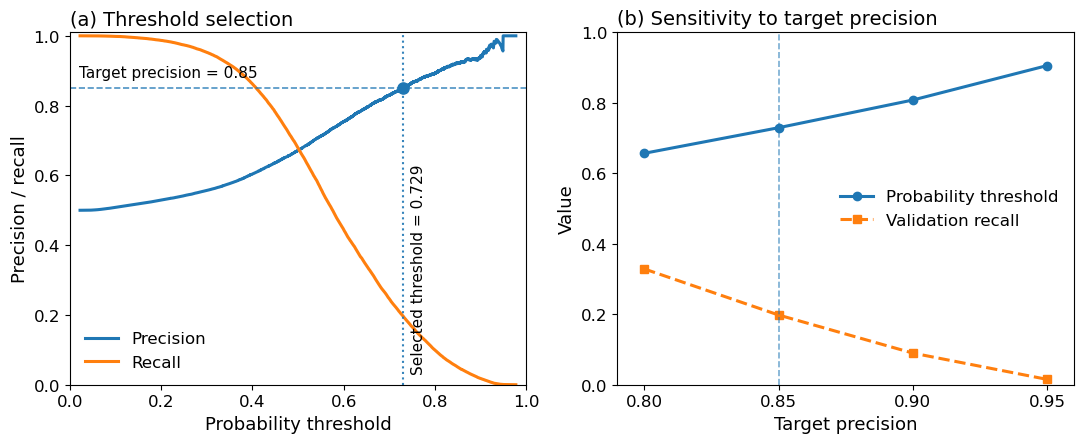

,target_precision,probability_threshold,validation_precision,validation_recall
0,0.80,0.657,0.800,0.329
1,0.85,0.729,0.850,0.198
2,0.90,0.808,0.900,0.090
3,0.95,0.906,0.951,0.015


In [45]:
# ------------------------------------------------------------
# SI FIGURE: threshold selection and sensitivity analysis
# ------------------------------------------------------------

SENSITIVITY_TARGETS = np.array([0.80, 0.85, 0.90, 0.95])

precision_val, recall_val, thresholds_val = precision_recall_curve(
    y_validation,
    p_validation,
)

# The final precision/recall pair returned by sklearn has no corresponding
# probability threshold and is therefore omitted here.
precision_by_threshold = precision_val[:-1]
recall_by_threshold = recall_val[:-1]

sensitivity_rows = []

for target in SENSITIVITY_TARGETS:
    info = threshold_for_target_precision(
        y_validation,
        p_validation,
        target_precision=float(target),
    )

    sensitivity_rows.append(
        {
            "target_precision": target,
            "probability_threshold": info["threshold"],
            "validation_precision": info["precision"],
            "validation_recall": info["recall"],
        }
    )

threshold_sensitivity = pd.DataFrame(sensitivity_rows)

threshold_sensitivity.to_csv(
    OUTPUT_DIR / "threshold_sensitivity_validation.csv",
    index=False,
)

# ------------------------------------------------------------
# Font sizes for this figure
# ------------------------------------------------------------

with plt.rc_context(
    {
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.6),
    )

    # --------------------------------------------------------
    # Panel (a): validation metrics across probability thresholds
    # --------------------------------------------------------

    ax = axes[0]

    ax.plot(
        thresholds_val,
        precision_by_threshold,
        linewidth=2.2,
        label="Precision",
    )

    ax.plot(
        thresholds_val,
        recall_by_threshold,
        linewidth=2.2,
        label="Recall",
    )

    ax.axhline(
        TARGET_PRECISION,
        linestyle="--",
        linewidth=1.2,
        alpha=0.8,
    )

    ax.axvline(
        SELECTED_THRESHOLD,
        linestyle=":",
        linewidth=1.5,
        alpha=0.9,
    )

    ax.scatter(
        SELECTED_THRESHOLD,
        threshold_info["precision"],
        s=65,
        zorder=4,
    )

    ax.annotate(
        f"Target precision = {TARGET_PRECISION:.2f}",
        xy=(0.02, TARGET_PRECISION),
        xycoords=("axes fraction", "data"),
        xytext=(0, 6),
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=11,
    )

    ax.annotate(
        f"Selected threshold = {SELECTED_THRESHOLD:.3f}",
        xy=(SELECTED_THRESHOLD, 0.03),
        xycoords="data",
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="bottom",
        rotation=90,
        fontsize=11,
    )

    ax.set(
        xlabel="Probability threshold",
        ylabel="Precision / recall",
        xlim=(0, 1),
        ylim=(0, 1.01),
    )

    ax.set_title(
        "(a) Threshold selection",
        loc="left",
    )

    ax.legend(
        frameon=False,
        loc="lower left",
    )

    # --------------------------------------------------------
    # Panel (b): sensitivity to target precision
    # --------------------------------------------------------

    ax = axes[1]

    ax.plot(
        threshold_sensitivity["target_precision"],
        threshold_sensitivity["probability_threshold"],
        marker="o",
        markersize=6,
        linewidth=2.2,
        label="Probability threshold",
    )

    ax.plot(
        threshold_sensitivity["target_precision"],
        threshold_sensitivity["validation_recall"],
        marker="s",
        markersize=6,
        linestyle="--",
        linewidth=2.2,
        label="Validation recall",
    )

    ax.axvline(
        TARGET_PRECISION,
        linestyle="--",
        linewidth=1.2,
        alpha=0.6,
    )

    ax.annotate(
        "",
        xy=(TARGET_PRECISION, 0.98),
        xycoords="data",
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=11,
    )

    ax.set(
        xlabel="Target precision",
        ylabel="Value",
        xlim=(
            SENSITIVITY_TARGETS.min() - 0.01,
            SENSITIVITY_TARGETS.max() + 0.01,
        ),
        ylim=(0, 1),
    )

    ax.set_xticks(SENSITIVITY_TARGETS)
    ax.set_xticklabels(
        [f"{value:.2f}" for value in SENSITIVITY_TARGETS]
    )

    ax.set_title(
        "(b) Sensitivity to target precision",
        loc="left",
    )

    ax.legend(
        frameon=False,
        loc="best",
    )

    fig.tight_layout()

    save_figure(
        fig,
        "threshold_selection_sensitivity_validation",
    )

    plt.show()

display(
    threshold_sensitivity.style.format(
        {
            "target_precision": "{:.2f}",
            "probability_threshold": "{:.3f}",
            "validation_precision": "{:.3f}",
            "validation_recall": "{:.3f}",
        }
    )
)

Written: /mnt/eo/EO4Backcasting/_figs/model_performance/model_performance_main.png
Written: /mnt/eo/EO4Backcasting/_figs/model_performance/model_performance_main.pdf


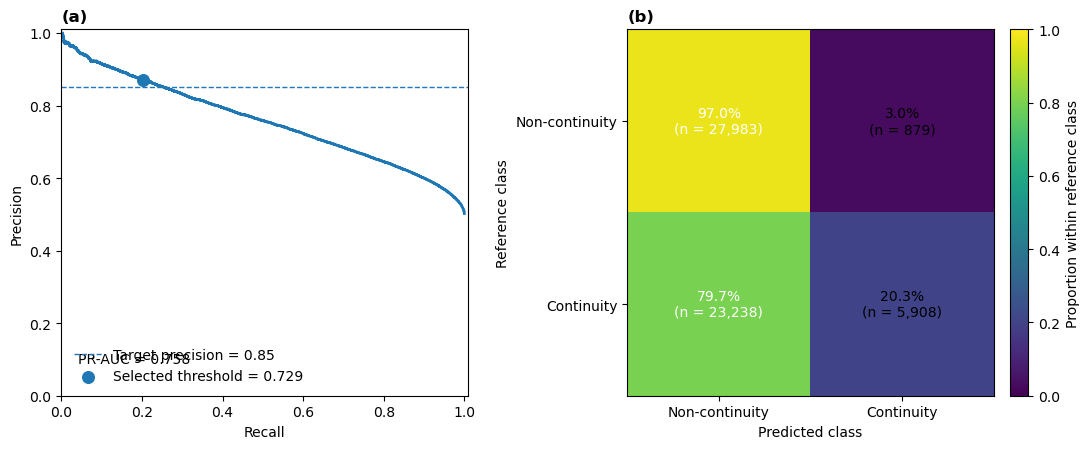

In [18]:
# ------------------------------------------------------------
# MAIN-TEXT FIGURE
# (a) precision–recall curve; (b) normalized confusion matrix
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

plot_precision_recall(
    axes[0],
    y_test,
    p_test,
    SELECTED_THRESHOLD,
)
axes[0].set_title("(a)", loc="left", fontweight="bold")

image = plot_normalized_confusion_matrix(
    axes[1],
    y_test,
    y_test_pred,
)
axes[1].set_title("(b)", loc="left", fontweight="bold")

colorbar = fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
colorbar.set_label("Proportion within reference class")

fig.tight_layout()
save_figure(fig, "model_performance_main")
plt.show()


Written: /mnt/eo/EO4Backcasting/_figs/model_performance/calibration_curve_test.png
Written: /mnt/eo/EO4Backcasting/_figs/model_performance/calibration_curve_test.pdf


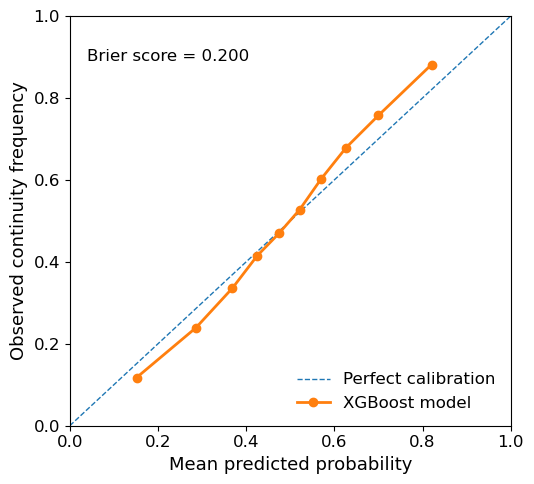

In [28]:
# ------------------------------------------------------------
# SI FIGURE: calibration plot
# ------------------------------------------------------------

fraction_positive, mean_predicted_probability = calibration_curve(
    y_test,
    p_test,
    n_bins=10,
    strategy="quantile",
)

with plt.rc_context(
    {
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
):

    fig, ax = plt.subplots(figsize=(5.5, 5))

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Perfect calibration",
    )

    ax.plot(
        mean_predicted_probability,
        fraction_positive,
        marker="o",
        linewidth=2,
        label="XGBoost model",
    )

    ax.set(
        xlabel="Mean predicted probability",
        ylabel="Observed continuity frequency",
        xlim=(0, 1),
        ylim=(0, 1),
    )

    ax.text(
        0.04,
        0.92,
        f"Brier score = {brier_score_loss(y_test, p_test):.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
    )

    ax.legend(frameon=False)

    fig.tight_layout()

    save_figure(fig, "calibration_curve_test")
    plt.show()

Written: /mnt/eo/EO4Backcasting/_figs/model_performance/roc_curve_test.png
Written: /mnt/eo/EO4Backcasting/_figs/model_performance/roc_curve_test.pdf


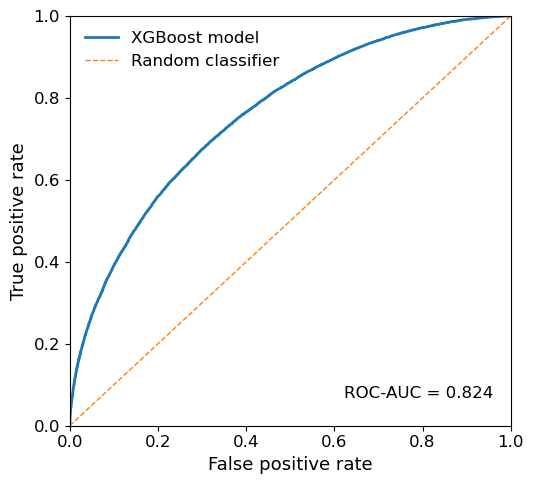

In [27]:
# ------------------------------------------------------------
# SI FIGURE: ROC curve
# ------------------------------------------------------------

false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    p_test,
)

roc_auc = roc_auc_score(
    y_test,
    p_test,
)

with plt.rc_context(
    {
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
):

    fig, ax = plt.subplots(figsize=(5.5, 5))

    ax.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label="XGBoost model",
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Random classifier",
    )

    ax.set(
        xlabel="False positive rate",
        ylabel="True positive rate",
        xlim=(0, 1),
        ylim=(0, 1),
    )

    # Legend moved away from the ROC-AUC annotation
    ax.legend(
        frameon=False,
        loc="upper left",
    )

    # Separate annotation in the lower-right corner
    ax.text(
        0.96,
        0.06,
        f"ROC-AUC = 0.824",
        transform=ax.transAxes,
        fontsize=12,
        ha="right",
        va="bottom",
    )

    fig.tight_layout()

    save_figure(fig, "roc_curve_test")
    plt.show()

Written: /mnt/eo/EO4Backcasting/_figs/model_performance/calibration_and_roc_test.png
Written: /mnt/eo/EO4Backcasting/_figs/model_performance/calibration_and_roc_test.pdf


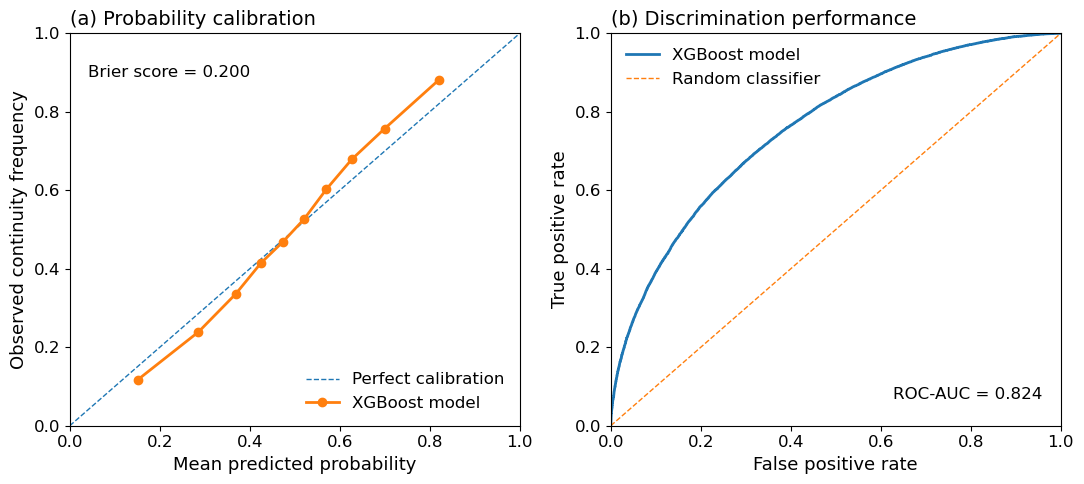

In [30]:
# ------------------------------------------------------------
# SI FIGURE: model calibration and discrimination performance
# ------------------------------------------------------------

# Calibration data
fraction_positive, mean_predicted_probability = calibration_curve(
    y_test,
    p_test,
    n_bins=10,
    strategy="quantile",
)

# ROC data
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    p_test,
)

roc_auc = roc_auc_score(
    y_test,
    p_test,
)

brier_score = brier_score_loss(
    y_test,
    p_test,
)

with plt.rc_context(
    {
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 5),
    )

    # --------------------------------------------------------
    # Panel (a): probability calibration
    # --------------------------------------------------------

    ax = axes[0]

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Perfect calibration",
    )

    ax.plot(
        mean_predicted_probability,
        fraction_positive,
        marker="o",
        linewidth=2,
        label="XGBoost model",
    )

    ax.set(
        xlabel="Mean predicted probability",
        ylabel="Observed continuity frequency",
        xlim=(0, 1),
        ylim=(0, 1),
    )

    ax.text(
        0.04,
        0.92,
        f"Brier score = {brier_score:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
    )

    ax.legend(
        frameon=False,
        loc="lower right",
    )

    ax.set_title(
        "(a) Probability calibration",
        loc="left",
    )

    # --------------------------------------------------------
    # Panel (b): discrimination performance
    # --------------------------------------------------------

    ax = axes[1]

    ax.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label="XGBoost model",
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Random classifier",
    )

    ax.set(
        xlabel="False positive rate",
        ylabel="True positive rate",
        xlim=(0, 1),
        ylim=(0, 1),
    )

    ax.legend(
        frameon=False,
        loc="upper left",
    )

    ax.text(
        0.96,
        0.06,
        f"ROC-AUC = 0.824",
        transform=ax.transAxes,
        fontsize=12,
        ha="right",
        va="bottom",
    )

    ax.set_title(
        "(b) Discrimination performance",
        loc="left",
    )

    fig.tight_layout()

    save_figure(
        fig,
        "calibration_and_roc_test",
    )

    plt.show()

In [31]:
# ------------------------------------------------------------
# Optional: export sample-level test predictions
# ------------------------------------------------------------

test_predictions = test_df[
    [column for column in ["point_id", "x", "y", TILE_COLUMN, LABEL_COLUMN]
     if column in test_df.columns]
].copy()

test_predictions["predicted_probability"] = p_test
test_predictions["predicted_class"] = y_test_pred

test_predictions.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
)

print(f"All outputs written to: {OUTPUT_DIR}")


All outputs written to: /mnt/eo/EO4Backcasting/_figs/model_performance


In [32]:
from sklearn.metrics import precision_recall_curve
import pandas as pd
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_validation,
    p_validation
)

threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

for target_precision in [0.90, 0.85, 0.80]:
    eligible = threshold_table[
        threshold_table["precision"] >= target_precision
    ]

    if len(eligible) > 0:
        row = eligible.iloc[0]

        print(
            f"Target precision: {target_precision:.2f} | "
            f"Threshold: {row['threshold']:.3f} | "
            f"Precision: {row['precision']:.3f} | "
            f"Recall: {row['recall']:.3f}"
        )

Target precision: 0.90 | Threshold: 0.808 | Precision: 0.900 | Recall: 0.090
Target precision: 0.85 | Threshold: 0.729 | Precision: 0.850 | Recall: 0.198
Target precision: 0.80 | Threshold: 0.657 | Precision: 0.800 | Recall: 0.329


In [33]:
# ------------------------------------------------------------
# Optional: compare sensitivity thresholds on the independent test set
# ------------------------------------------------------------

rows = []

for _, sensitivity_row in threshold_sensitivity.iterrows():
    target_precision = sensitivity_row["target_precision"]
    threshold = sensitivity_row["probability_threshold"]
    y_pred = (p_test >= threshold).astype("uint8")

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1],
    ).ravel()

    rows.append(
        {
            "scenario": f"precision_{target_precision:.2f}",
            "target_precision": target_precision,
            "threshold": threshold,
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "true_positives": tp,
            "false_positives": fp,
            "false_negatives": fn,
            "true_negatives": tn,
        }
    )

threshold_test_comparison = pd.DataFrame(rows)
threshold_test_comparison


,scenario,target_precision,threshold,precision,recall,f1,specificity,balanced_accuracy,true_positives,false_positives,false_negatives,true_negatives
0,precision_0.80,0.80,0.656726,0.817913,0.332739,0.473039,0.925196,0.628967,9698,2159,19448,26703
1,precision_0.85,0.85,0.729315,0.870488,0.202704,0.328834,0.969545,0.586124,5908,879,23238,27983
2,precision_0.90,0.90,0.807941,0.917361,0.094455,0.171276,0.991407,0.542931,2753,248,26393,28614
3,precision_0.95,0.95,0.905659,0.971774,0.016537,0.032521,0.999515,0.508026,482,14,28664,28848


In [26]:
# Use the main target precision (0.85) as the sensitivity-analysis baseline.
baseline_idx = np.argmin(
    np.abs(
        threshold_test_comparison["target_precision"].to_numpy()
        - TARGET_PRECISION
    )
)
baseline = threshold_test_comparison.iloc[baseline_idx]

threshold_test_comparison["additional_true_positives"] = (
    threshold_test_comparison["true_positives"]
    - baseline["true_positives"]
)

threshold_test_comparison["additional_false_positives"] = (
    threshold_test_comparison["false_positives"]
    - baseline["false_positives"]
)

threshold_test_comparison["additional_tp_per_additional_fp"] = np.divide(
    threshold_test_comparison["additional_true_positives"],
    threshold_test_comparison["additional_false_positives"],
    out=np.full(len(threshold_test_comparison), np.nan, dtype=float),
    where=threshold_test_comparison["additional_false_positives"] != 0,
)

threshold_test_comparison


,scenario,threshold,precision,recall,f1,specificity,balanced_accuracy,true_positives,false_positives,false_negatives,true_negatives,additional_true_positives,additional_false_positives,additional_tp_per_additional_fp
0,precision_0.90,0.808,0.917306,0.094387,0.171162,0.991407,0.542897,2751,248,26395,28614,0,0,NaN
1,precision_0.85,0.729,0.870471,0.203596,0.330006,0.969406,0.586501,5934,883,23212,27979,3183,635,5.012598
2,precision_0.80,0.657,0.818020,0.332052,0.472363,0.925404,0.628728,9678,2153,19468,26709,6927,1905,3.636220


In [47]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)

y_test_binary = (p_test >= SELECTED_THRESHOLD).astype(int)

print(
    f"PR-AUC: {average_precision_score(y_test, p_test):.3f} | "
    f"ROC-AUC: {roc_auc_score(y_test, p_test):.3f} | "
    f"Precision: {precision_score(y_test, y_test_binary, pos_label=1):.3f} | "
    f"Recall: {recall_score(y_test, y_test_binary, pos_label=1):.3f} | "
    f"F1: {f1_score(y_test, y_test_binary, pos_label=1):.3f}"
)

PR-AUC: 0.758 | ROC-AUC: 0.760 | Precision: 0.870 | Recall: 0.203 | F1: 0.329
